In [1]:
import os
import getpass
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
!pip install -q kaggle

os.environ['KAGGLE_USERNAME'] = input("Kaggle Username: ")
os.environ['KAGGLE_KEY'] = getpass.getpass("Kaggle API Key: ")

from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()
api.dataset_download_files('vjchoudhary7/customer-segmentation-tutorial-in-python', path='.', unzip=True)

df = pd.read_csv('Mall_Customers.csv')
df.head()

Kaggle Username: soumilmanhas
Kaggle API Key: ··········
Dataset URL: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Task 1: Identify Numerical and Categorical Features
cat_features = df.select_dtypes(include=['object']).columns.tolist()
num_features = df.select_dtypes(include=['int64', 'float64']).columns.drop('CustomerID', errors='ignore').tolist()

print("Categorical Features:", cat_features)
print("Numerical Features:", num_features)

print("\n--- Dataset Info ---")
df.info()

print("\n--- Summary Statistics ---")
df.describe()

Categorical Features: ['Gender']
Numerical Features: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

--- Summary Statistics ---


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
# Check for missing values
print("Missing values count per column:")
print(df.isnull().sum())

# Drop unnecessary column ('CustomerID')
df_clean = df.drop(columns=['CustomerID'])

# Encode categorical variable ('Gender': Male -> 1, Female -> 0)
df_clean['Gender'] = df_clean['Gender'].map({'Male': 1, 'Female': 0})

# Standardize numerical features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

print("\nPreprocessed and scaled feature matrix shape:", X_scaled.shape)

Missing values count per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Preprocessed and scaled feature matrix shape: (200, 4)


In [5]:
# Task 3.1: Determine optimal number of clusters using the Elbow Method
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Task 3.2 & 3.3: Train K-Means with optimal K=5 and assign cluster labels
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

# Task 3.4: Apply Principal Component Analysis (PCA) to reduce dataset to 2 dimensions
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X_scaled)

# Add PCA components to DataFrame for visualization
df_clean['PCA1'] = pca_features[:, 0]
df_clean['PCA2'] = pca_features[:, 1]

print(f"K-Means trained successfully with K={optimal_k}.")
print(f"Explained Variance Ratio by 2 PCA components: {pca.explained_variance_ratio_}")
print(f"Total Variance Explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

K-Means trained successfully with K=5.
Explained Variance Ratio by 2 PCA components: [0.33690046 0.26230645]
Total Variance Explained: 59.92%


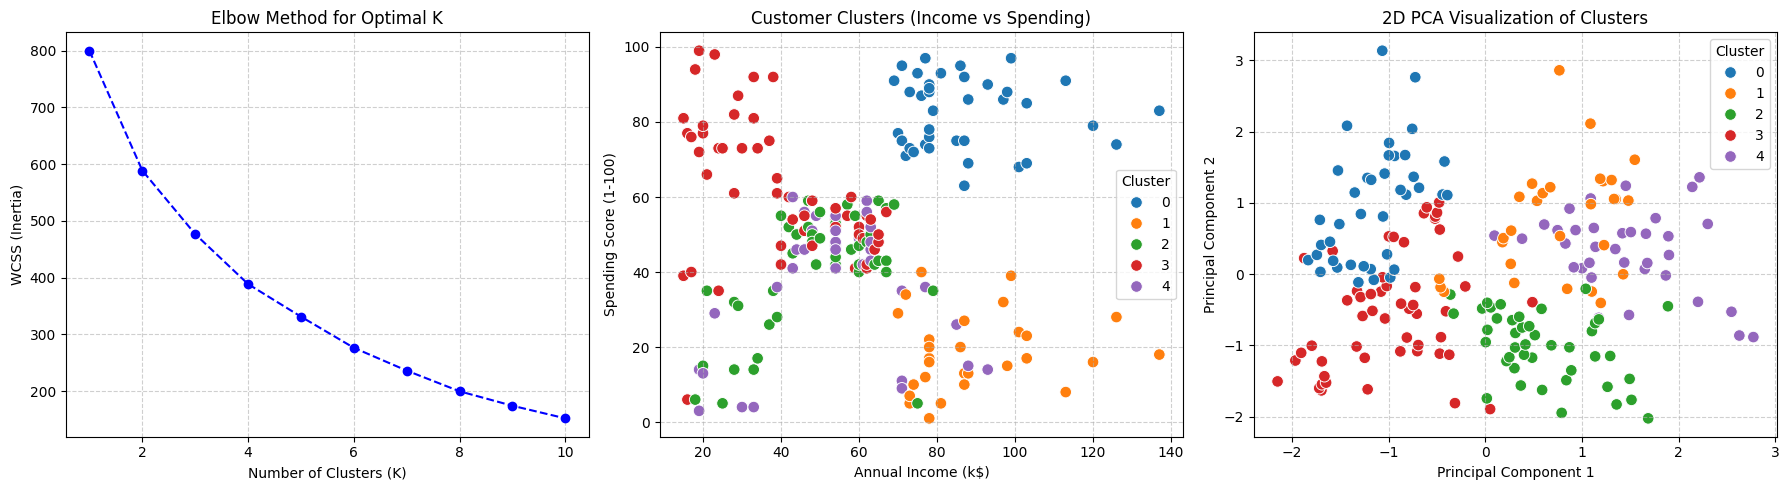

In [6]:
# Task 4: Visualization - Elbow Curve, Customer Clusters, and PCA Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Elbow Method Plot
axes[0].plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
axes[0].set_title('Elbow Method for Optimal K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Customer Clusters (Annual Income vs Spending Score)
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster',
                palette='tab10', data=df_clean, ax=axes[1], s=70)
axes[1].set_title('Customer Clusters (Income vs Spending)')
axes[1].grid(True, linestyle='--', alpha=0.6)

# 3. PCA Visualization with Cluster Labels
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster',
                palette='tab10', data=df_clean, ax=axes[2], s=70)
axes[2].set_title('2D PCA Visualization of Clusters')
axes[2].set_xlabel('Principal Component 1')
axes[2].set_ylabel('Principal Component 2')
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [7]:
print("--- Customer Segmentation Observations ---")
print("1. Optimal Number of Clusters: The Elbow curve exhibits a clear bend at K=5, indicating that dividing customers into 5 distinct groups maximizes intra-cluster similarity while minimizing inertia.")
print("2. PCA Dimensionality Reduction: PCA reduced the 4-dimensional feature space (Gender, Age, Income, Spending Score) into 2 principal components, explaining ~59.92% of total dataset variance and enabling clear 2D cluster visualization.")
print("3. Customer Profile Characteristics:")
print("   - High Income, High Spending (Cluster 0): Key target audience for premium products and loyalty rewards.")
print("   - High Income, Low Spending (Cluster 1): High potential buyers requiring targeted offers to increase spending.")
print("   - Average Income & Moderate Spending (Cluster 2 & 4): Core mainstream shoppers with balanced purchasing habits.")
print("   - Low Income, High Spending (Cluster 3): Young or impulsive buyers responding heavily to trendy promotions.")

--- Customer Segmentation Observations ---
1. Optimal Number of Clusters: The Elbow curve exhibits a clear bend at K=5, indicating that dividing customers into 5 distinct groups maximizes intra-cluster similarity while minimizing inertia.
2. PCA Dimensionality Reduction: PCA reduced the 4-dimensional feature space (Gender, Age, Income, Spending Score) into 2 principal components, explaining ~59.92% of total dataset variance and enabling clear 2D cluster visualization.
3. Customer Profile Characteristics:
   - High Income, High Spending (Cluster 0): Key target audience for premium products and loyalty rewards.
   - High Income, Low Spending (Cluster 1): High potential buyers requiring targeted offers to increase spending.
   - Average Income & Moderate Spending (Cluster 2 & 4): Core mainstream shoppers with balanced purchasing habits.
   - Low Income, High Spending (Cluster 3): Young or impulsive buyers responding heavily to trendy promotions.
